# 1.Clear Statement of the Business Task (ASK Phase)

Cyclistic aims to increase the number of annual memberships, as these provide more stable and predictable revenue compared to casual riders.

✅ **Business Task**

Analyze how casual riders and annual members use Cyclistic bikes differently in order to:

- Identify behavioral patterns between the two groups
- Understand what motivates casual riders
- Develop data-driven marketing strategies to convert casual riders into annual members

🎯 **Key Questions** 

- How do annual members and casual riders use Cyclistic bikes differently?
- Why would casual riders purchase annual memberships?
- How can digital media encourage casual riders to become members?

# 2.How This Data Helps Answer the Business Problem

This dataset allows you to:

- Compare ride frequency and duration
- Identify usage patterns (weekday vs weekend)
- Analyze seasonal trends
- Understand behavior differences between casual and members

➡️ **These insights directly support marketing decisions such as:**

- Pricing strategies
- Membership incentives
- Targeted campaigns

In [1]:
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as px
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
case_file_1 = pd.read_csv("/kaggle/input/privat/202401-divvy-tripdata.csv")
case_file_2 = pd.read_csv("/kaggle/input/privat/202402-divvy-tripdata.csv")
case_file_3 = pd.read_csv("/kaggle/input/privat/202403-divvy-tripdata.csv")
case_file_4 = pd.read_csv("/kaggle/input/privat/202404-divvy-tripdata.csv")
case_file_5 = pd.read_csv("/kaggle/input/privat/202405-divvy-tripdata.csv")
case_file_6 = pd.read_csv("/kaggle/input/privat/202406-divvy-tripdata.csv")
case_file_7 = pd.read_csv("/kaggle/input/privat/202407-divvy-tripdata.csv")
case_file_8 = pd.read_csv("/kaggle/input/privat/202408-divvy-tripdata.csv")
case_file_9 = pd.read_csv("/kaggle/input/privat/202409-divvy-tripdata.csv")
case_file_10 = pd.read_csv("/kaggle/input/privat/202410-divvy-tripdata.csv")

# 1.Combine all datasets

In [3]:
import pandas as pd

# Combine all files into a list
files = [
    case_file_1, case_file_2, case_file_3, case_file_4, case_file_5,
    case_file_6, case_file_7, case_file_8, case_file_9, case_file_10
]

# Concatenate
df = pd.concat(files, ignore_index=True)

# Preview
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,C1D650626C8C899A,electric_bike,2024-01-12 15:30:27,2024-01-12 15:37:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.903267,-87.634737,41.889177,-87.638506,member
1,EECD38BDB25BFCB0,electric_bike,2024-01-08 15:45:46,2024-01-08 15:52:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902937,-87.634440,41.889177,-87.638506,member
2,F4A9CE78061F17F7,electric_bike,2024-01-27 12:27:19,2024-01-27 12:35:19,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902951,-87.634470,41.889177,-87.638506,member
3,0A0D9E15EE50B171,classic_bike,2024-01-29 16:26:17,2024-01-29 16:56:06,Wells St & Randolph St,TA1305000030,Larrabee St & Webster Ave,13193,41.884295,-87.633963,41.921822,-87.644140,member
4,33FFC9805E3EFF9A,classic_bike,2024-01-31 05:43:23,2024-01-31 06:09:35,Lincoln Ave & Waveland Ave,13253,Kingsbury St & Kinzie St,KA1503000043,41.948797,-87.675278,41.889177,-87.638506,member


# 2.Initial inspection

Check structure and missing values:

In [4]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5347121 entries, 0 to 5347120
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 530.3+ MB


ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name     988557
start_station_id       988557
end_station_name      1016233
end_station_id        1016233
start_lat                   0
start_lng                   0
end_lat                  6828
end_lng                  6828
member_casual               0
dtype: int64

# 3.Data cleaning

Typical cleaning steps for Divvy data:

In [5]:
df['started_at'] = pd.to_datetime(df['started_at'], format='mixed')
df['ended_at'] = pd.to_datetime(df['ended_at'], format='mixed')

**Create ride duration**

In [6]:
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

**Remove invalid rides**

In [7]:
df = df[df['ride_length'] > 0]

**Extract useful features**

In [8]:
df['day_of_week'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month_name()
df['hour'] = df['started_at'].dt.hour

# 4.Exploratory Data Analysis (EDA)

Compare member vs casual riders

In [9]:
df['member_casual'].value_counts()

member_casual
member    3326475
casual    2019966
Name: count, dtype: int64

**Average ride length**

In [10]:
df.groupby('member_casual')['ride_length'].mean()

member_casual
casual    25.555382
member    12.978656
Name: ride_length, dtype: float64

**Rides by day of week**

In [11]:
df.groupby(['day_of_week', 'member_casual']).size().unstack()

member_casual,casual,member
day_of_week,,
Friday,294862,466510
Monday,235748,471307
Saturday,419752,431016
Sunday,346747,372639
Thursday,251763,523479
Tuesday,216148,507104
Wednesday,254946,554420


**Rides by hour**

In [12]:
df.groupby(['hour', 'member_casual']).size().unstack()

member_casual,casual,member
hour,,
0,32852,29244
1,21720,17786
2,13489,10018
3,7452,6843
4,5760,7713
5,11265,30778
6,26327,92492
7,48976,177501
8,69208,225272


# 5.Visualization

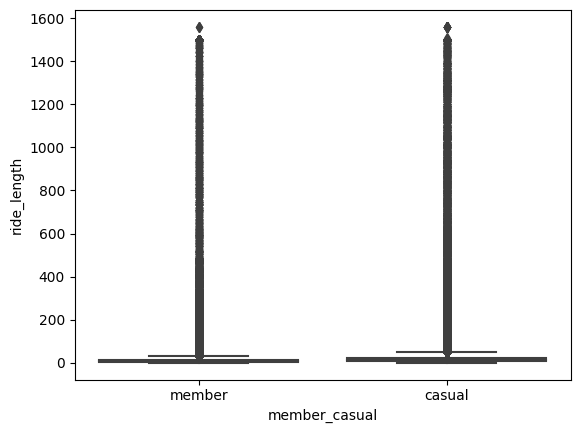

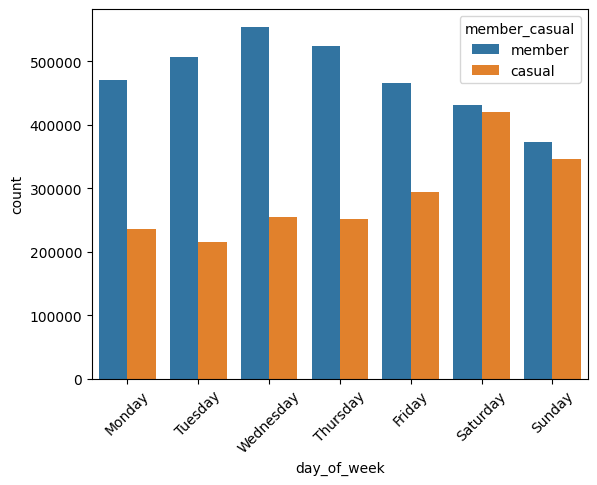

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ride length distribution
sns.boxplot(x='member_casual', y='ride_length', data=df)
plt.show()

# Rides per weekday
sns.countplot(x='day_of_week', hue='member_casual', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.xticks(rotation=45)
plt.show()

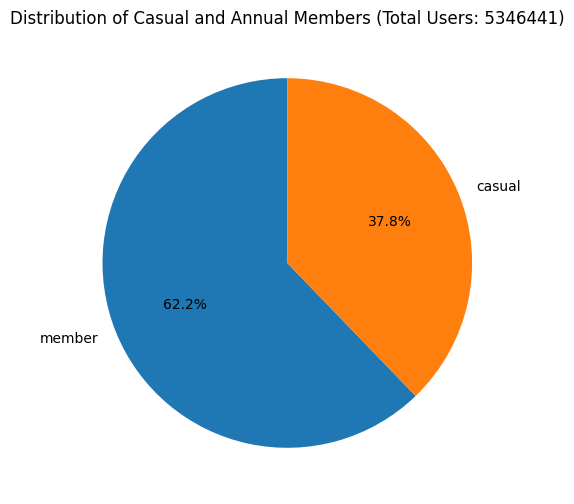

In [14]:
user_type_counts = df['member_casual'].value_counts()

# Create   chart with total number of users
plt.figure(figsize=(10, 6))
plt.pie(user_type_counts, labels=user_type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Casual and Annual Members (Total Users: {})'.format(len(df)))
plt.show()

# Clustering (User Behavior Segmentation)

In [15]:
import numpy as np

# Basic features
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Encode categorical
df['member'] = df['member_casual'].map({'member': 1, 'casual': 0})

# Select features for clustering
features = df[['ride_length', 'hour', 'is_weekend', 'member']].dropna()

**Scale + KMeans**

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
features['cluster'] = kmeans.fit_predict(X_scaled)

**Interpret clusters**

In [17]:
features.groupby('cluster').mean()

,ride_length,hour,is_weekend,member
cluster,,,,
0,18.334656,13.809030,1.000000,0.512728
1,11.736076,13.985897,0.000000,1.000000
2,1382.743007,14.506647,0.389904,0.206273
3,18.550691,14.725236,0.000000,0.000000


- Cluster 0 → Short weekday rides → commuters
- Cluster 1 → Long weekend rides → tourists/casual
- Cluster 2 → Night rides → leisure users
- Cluster 3 → Mixed behavior

# Station Popularity Analysis

**Top start stations**

In [18]:
top_start = df['start_station_name'].value_counts().head(10)
print(top_start)

start_station_name
Streeter Dr & Grand Ave               63003
DuSable Lake Shore Dr & Monroe St     41996
DuSable Lake Shore Dr & North Blvd    38477
Michigan Ave & Oak St                 38019
Kingsbury St & Kinzie St              34912
Clark St & Elm St                     31967
Millennium Park                       31090
Clinton St & Washington Blvd          30551
Wells St & Concord Ln                 29254
Clinton St & Madison St               29221
Name: count, dtype: int64


**Top end stations**

In [19]:
top_end = df['end_station_name'].value_counts().head(10)
print(top_end)

end_station_name
Streeter Dr & Grand Ave               64121
DuSable Lake Shore Dr & North Blvd    41919
DuSable Lake Shore Dr & Monroe St     40898
Michigan Ave & Oak St                 37924
Kingsbury St & Kinzie St              34424
Clark St & Elm St                     31503
Millennium Park                       31093
Clinton St & Washington Blvd          30886
Clinton St & Madison St               29766
Theater on the Lake                   29613
Name: count, dtype: int64


**Member vs Casual station usage**

In [20]:
station_usage = df.groupby(['start_station_name', 'member_casual']).size().unstack().fillna(0)

# Top stations for casual riders
top_casual = station_usage.sort_values(by='casual', ascending=False).head(10)

# Top stations for members
top_member = station_usage.sort_values(by='member', ascending=False).head(10)

In [21]:
top_casual

member_casual,casual,member
start_station_name,,
Streeter Dr & Grand Ave,48934.0,14069.0
DuSable Lake Shore Dr & Monroe St,32524.0,9472.0
Michigan Ave & Oak St,24379.0,13640.0
DuSable Lake Shore Dr & North Blvd,22596.0,15881.0
Millennium Park,21501.0,9589.0
Shedd Aquarium,19710.0,4481.0
Dusable Harbor,17632.0,6383.0
Theater on the Lake,16496.0,12333.0
Michigan Ave & 8th St,12895.0,6553.0


In [22]:
top_member

member_casual,casual,member
start_station_name,,
Kingsbury St & Kinzie St,9257.0,25655.0
Clinton St & Washington Blvd,6128.0,24423.0
Clark St & Elm St,10075.0,21892.0
Clinton St & Madison St,7342.0,21879.0
Wells St & Concord Ln,10731.0,18523.0
Wells St & Elm St,9334.0,18100.0
Clinton St & Jackson Blvd,5757.0,17727.0
Dearborn St & Erie St,7708.0,17333.0
State St & Chicago Ave,7360.0,16690.0


# Geospatial Analysis (Maps)

We’ll use Folium to visualize rides and stations.

In [23]:
!pip install folium

**Base map**

In [24]:
import folium

# Center around Chicago (Divvy default)
m = folium.Map(location=[41.8781, -87.6298], zoom_start=12)
m

**Plot popular stations**

In [25]:
# Drop missing coordinates
stations = df.dropna(subset=['start_lat', 'start_lng'])

# Top stations with coordinates
top_stations = stations.groupby(
    ['start_station_name', 'start_lat', 'start_lng']
).size().reset_index(name='count').sort_values(by='count', ascending=False).head(20)

for _, row in top_stations.iterrows():
    folium.CircleMarker(
        location=[row['start_lat'], row['start_lng']],
        radius=5,
        popup=row['start_station_name'],
        color='blue',
        fill=True
    ).add_to(m)

m

In [26]:
import numpy as np

# Ride length
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# Time features
df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.dayofweek  # 0=Monday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Optional: rush hour flag
df['is_rush_hour'] = df['hour'].isin([7,8,9,16,17,18]).astype(int)

In [27]:
from sklearn.model_selection import train_test_split

# Encode target
df['target'] = df['member_casual'].map({'member': 1, 'casual': 0})

features = ['ride_length', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour']

X = df[features].dropna()
y = df.loc[X.index, 'target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model (Logistic Regression)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Evaluate Model

In [29]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.63      0.20      0.31    403783
           1       0.66      0.93      0.77    665506

    accuracy                           0.65   1069289
   macro avg       0.65      0.57      0.54   1069289
weighted avg       0.65      0.65      0.59   1069289

ROC-AUC: 0.6431953584563452


# Apply Model to Casual Riders

In [30]:
casual_df = df[df['member_casual'] == 'casual'].copy()

X_casual = casual_df[features].dropna()

# Predict probability of being "member-like"
casual_df.loc[X_casual.index, 'conversion_score'] = model.predict_proba(X_casual)[:, 1]

# Identify High-Conversion Users

In [31]:
high_potential = casual_df[casual_df['conversion_score'] > 0.7]

high_potential[['ride_length', 'hour', 'is_weekend', 'conversion_score']].head()

,ride_length,hour,is_weekend,conversion_score
185,4.316667,16,0,0.717188
213,4.050000,12,0,0.708239
262,3.833333,18,0,0.740370
277,10.916667,17,0,0.712642
282,5.800000,17,0,0.718541


# Feature Importance (Explainability)

In [32]:
import pandas as pd

importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print(importance)

        feature  coefficient
4  is_rush_hour     0.282017
0   ride_length    -0.015520
1          hour    -0.020723
2   day_of_week    -0.050427
3    is_weekend    -0.399205


>“Casual riders who exhibit commuting behavior (weekday, rush hour, short rides) have the highest probability of converting to members.”

 # Conversion Score Distribution

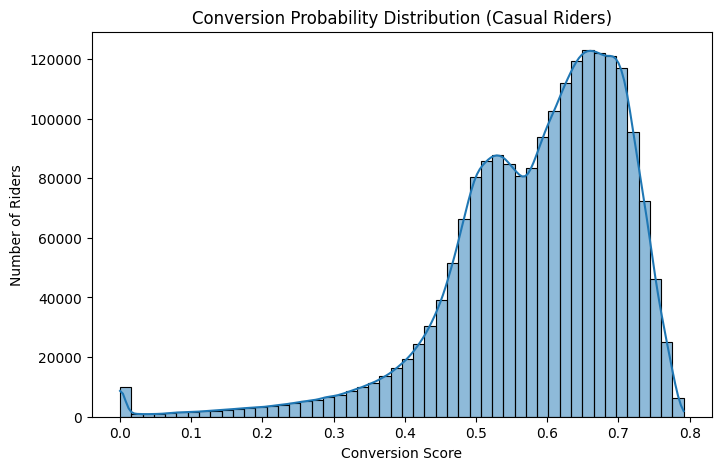

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(casual_df['conversion_score'], bins=50, kde=True)
plt.title("Conversion Probability Distribution (Casual Riders)")
plt.xlabel("Conversion Score")
plt.ylabel("Number of Riders")
plt.show()

# Segment Users (Low / Medium / High)

In [34]:
def segment(score):
    if score < 0.3:
        return 'Low'
    elif score < 0.7:
        return 'Medium'
    else:
        return 'High'

casual_df['segment'] = casual_df['conversion_score'].apply(segment)

# Segment Distribution

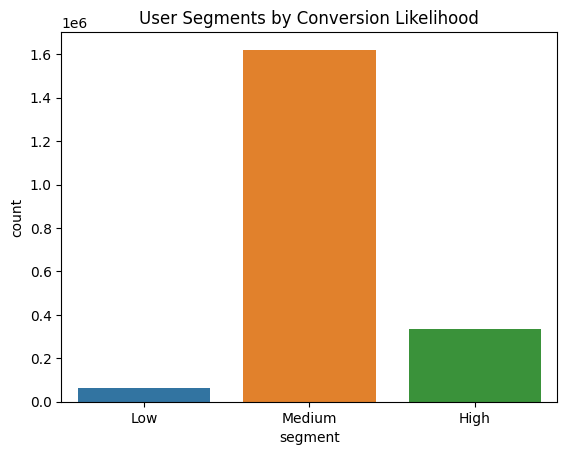

In [35]:
sns.countplot(x='segment', data=casual_df, order=['Low','Medium','High'])
plt.title("User Segments by Conversion Likelihood")
plt.show()

# Behavioral Comparison by Segment

**Ride length**

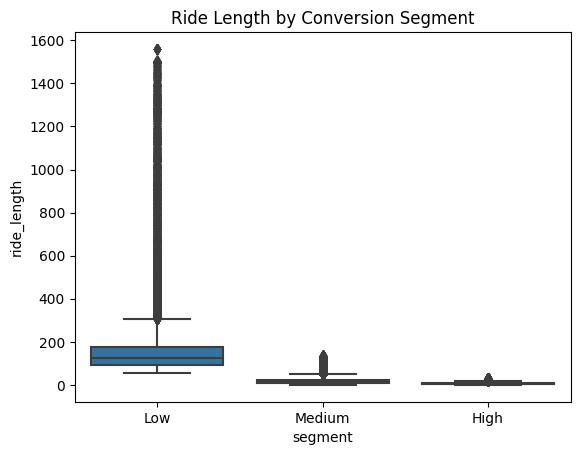

In [36]:
sns.boxplot(x='segment', y='ride_length', data=casual_df,
            order=['Low','Medium','High'])
plt.title("Ride Length by Conversion Segment")
plt.show()

**Hour of day**

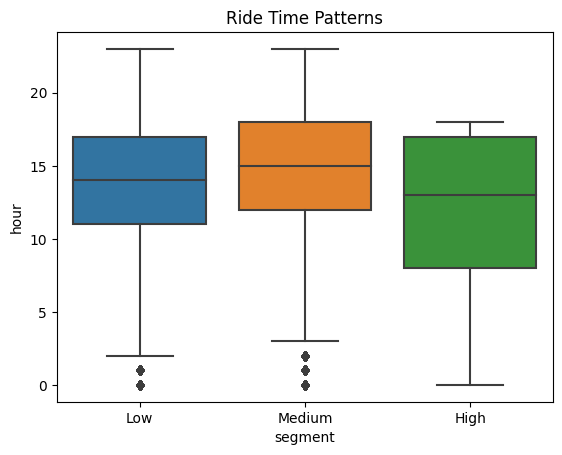

In [37]:
sns.boxplot(x='segment', y='hour', data=casual_df,
            order=['Low','Medium','High'])
plt.title("Ride Time Patterns")
plt.show()

**Weekend vs weekday**

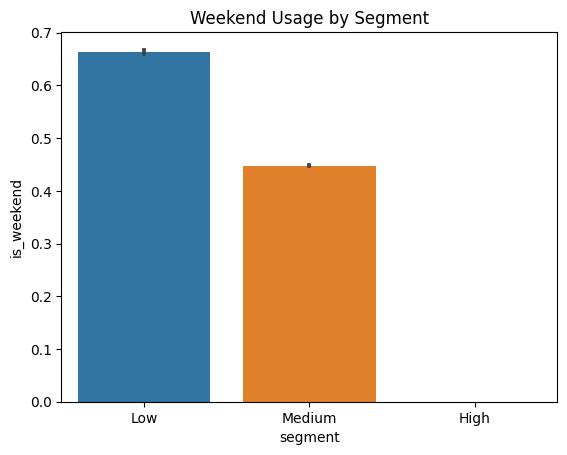

In [38]:
sns.barplot(x='segment', y='is_weekend', data=casual_df,
            order=['Low','Medium','High'])
plt.title("Weekend Usage by Segment")
plt.show()

# Top Stations for High-Conversion Users

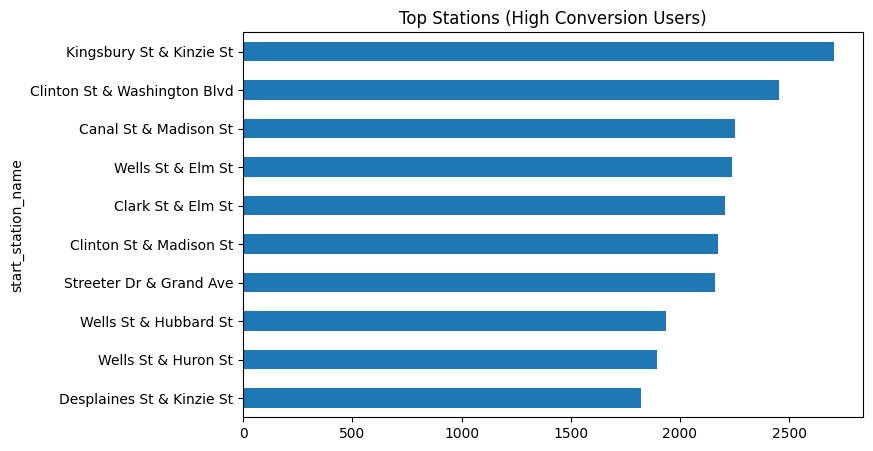

In [39]:
high_users = casual_df[casual_df['segment'] == 'High']

top_stations = high_users['start_station_name'].value_counts().head(10)

top_stations.plot(kind='barh', figsize=(8,5))
plt.title("Top Stations (High Conversion Users)")
plt.gca().invert_yaxis()
plt.show()

# Interactive Dashboard

In [40]:
import plotly.io as pio
pio.renderers.default = 'iframe'

fig = px.histogram(
    casual_df,
    x='conversion_score',
    nbins=50,
    title="Conversion Score Distribution"
)

fig.show()

“Casual riders were segmented into low, medium, and high conversion groups using a predictive model.
High-conversion users display commuting behavior—short rides during weekdays and peak hours.
These users represent the strongest opportunity for membership conversion and should be targeted with personalized pricing and commuter-focused marketing.”

# Bias, Privacy, and Limitations

⚠️ **Bias Considerations**

- Data only reflects existing users, not potential customers
- Lack of demographic data limits understanding of user segments
- Seasonal bias (only 10 months, not full year)
🔒 **Privacy & Security**

- Dataset is anonymized (no personally identifiable information)
- Complies with data privacy standards
- 
📜 **Licensing**

- Used under Motivate International Inc. license
- Appropriate for analysis and case study use